In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
delays_2024 = pd.read_excel("ttc-streetcar-delay-data-2024.xlsx")
# find out 5 first rows
delays_2024.head()

,Date,Line,Time,Day,Location,Incident,Min Delay,Min Gap,Bound,Vehicle
0,2024-01-01,505,02:45,Monday,DUNDAS AND MCCAUL,Security,10,20,W,4416
1,2024-01-01,505,03:06,Monday,COLLEGE AND GLADSTONE,Emergency Services,52,72,E,4461
2,2024-01-01,503,03:21,Monday,PARLIAMENT AND SHUTTER,Security,0,0,N,4545
3,2024-01-01,505,03:53,Monday,DUNDAS WEST STATION,Security,37,0,W,4551
4,2024-01-01,600,04:27,Monday,QUEEN AND BATHURST,Diversion,78,93,E,8116


In [3]:
delays_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14206 entries, 0 to 14205
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       14206 non-null  datetime64[ns]
 1   Line       14050 non-null  object        
 2   Time       14206 non-null  object        
 3   Day        14206 non-null  object        
 4   Location   14205 non-null  object        
 5   Incident   14206 non-null  object        
 6   Min Delay  14206 non-null  int64         
 7   Min Gap    14206 non-null  int64         
 8   Bound      12078 non-null  object        
 9   Vehicle    14206 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 1.1+ MB


In [4]:
delays_2024 = delays_2024.copy() # make a copy of dataframe
delays_2024['Date'] = pd.to_datetime(delays_2024['Date']) # transform "Date" column to datetime format
daily_counts = delays_2024.groupby(delays_2024['Date'].dt.date).size().reset_index(name='number_delay') # Aggregate by counting the number of delays for each day


## Create publication grade time series plot for daily delays in 2024

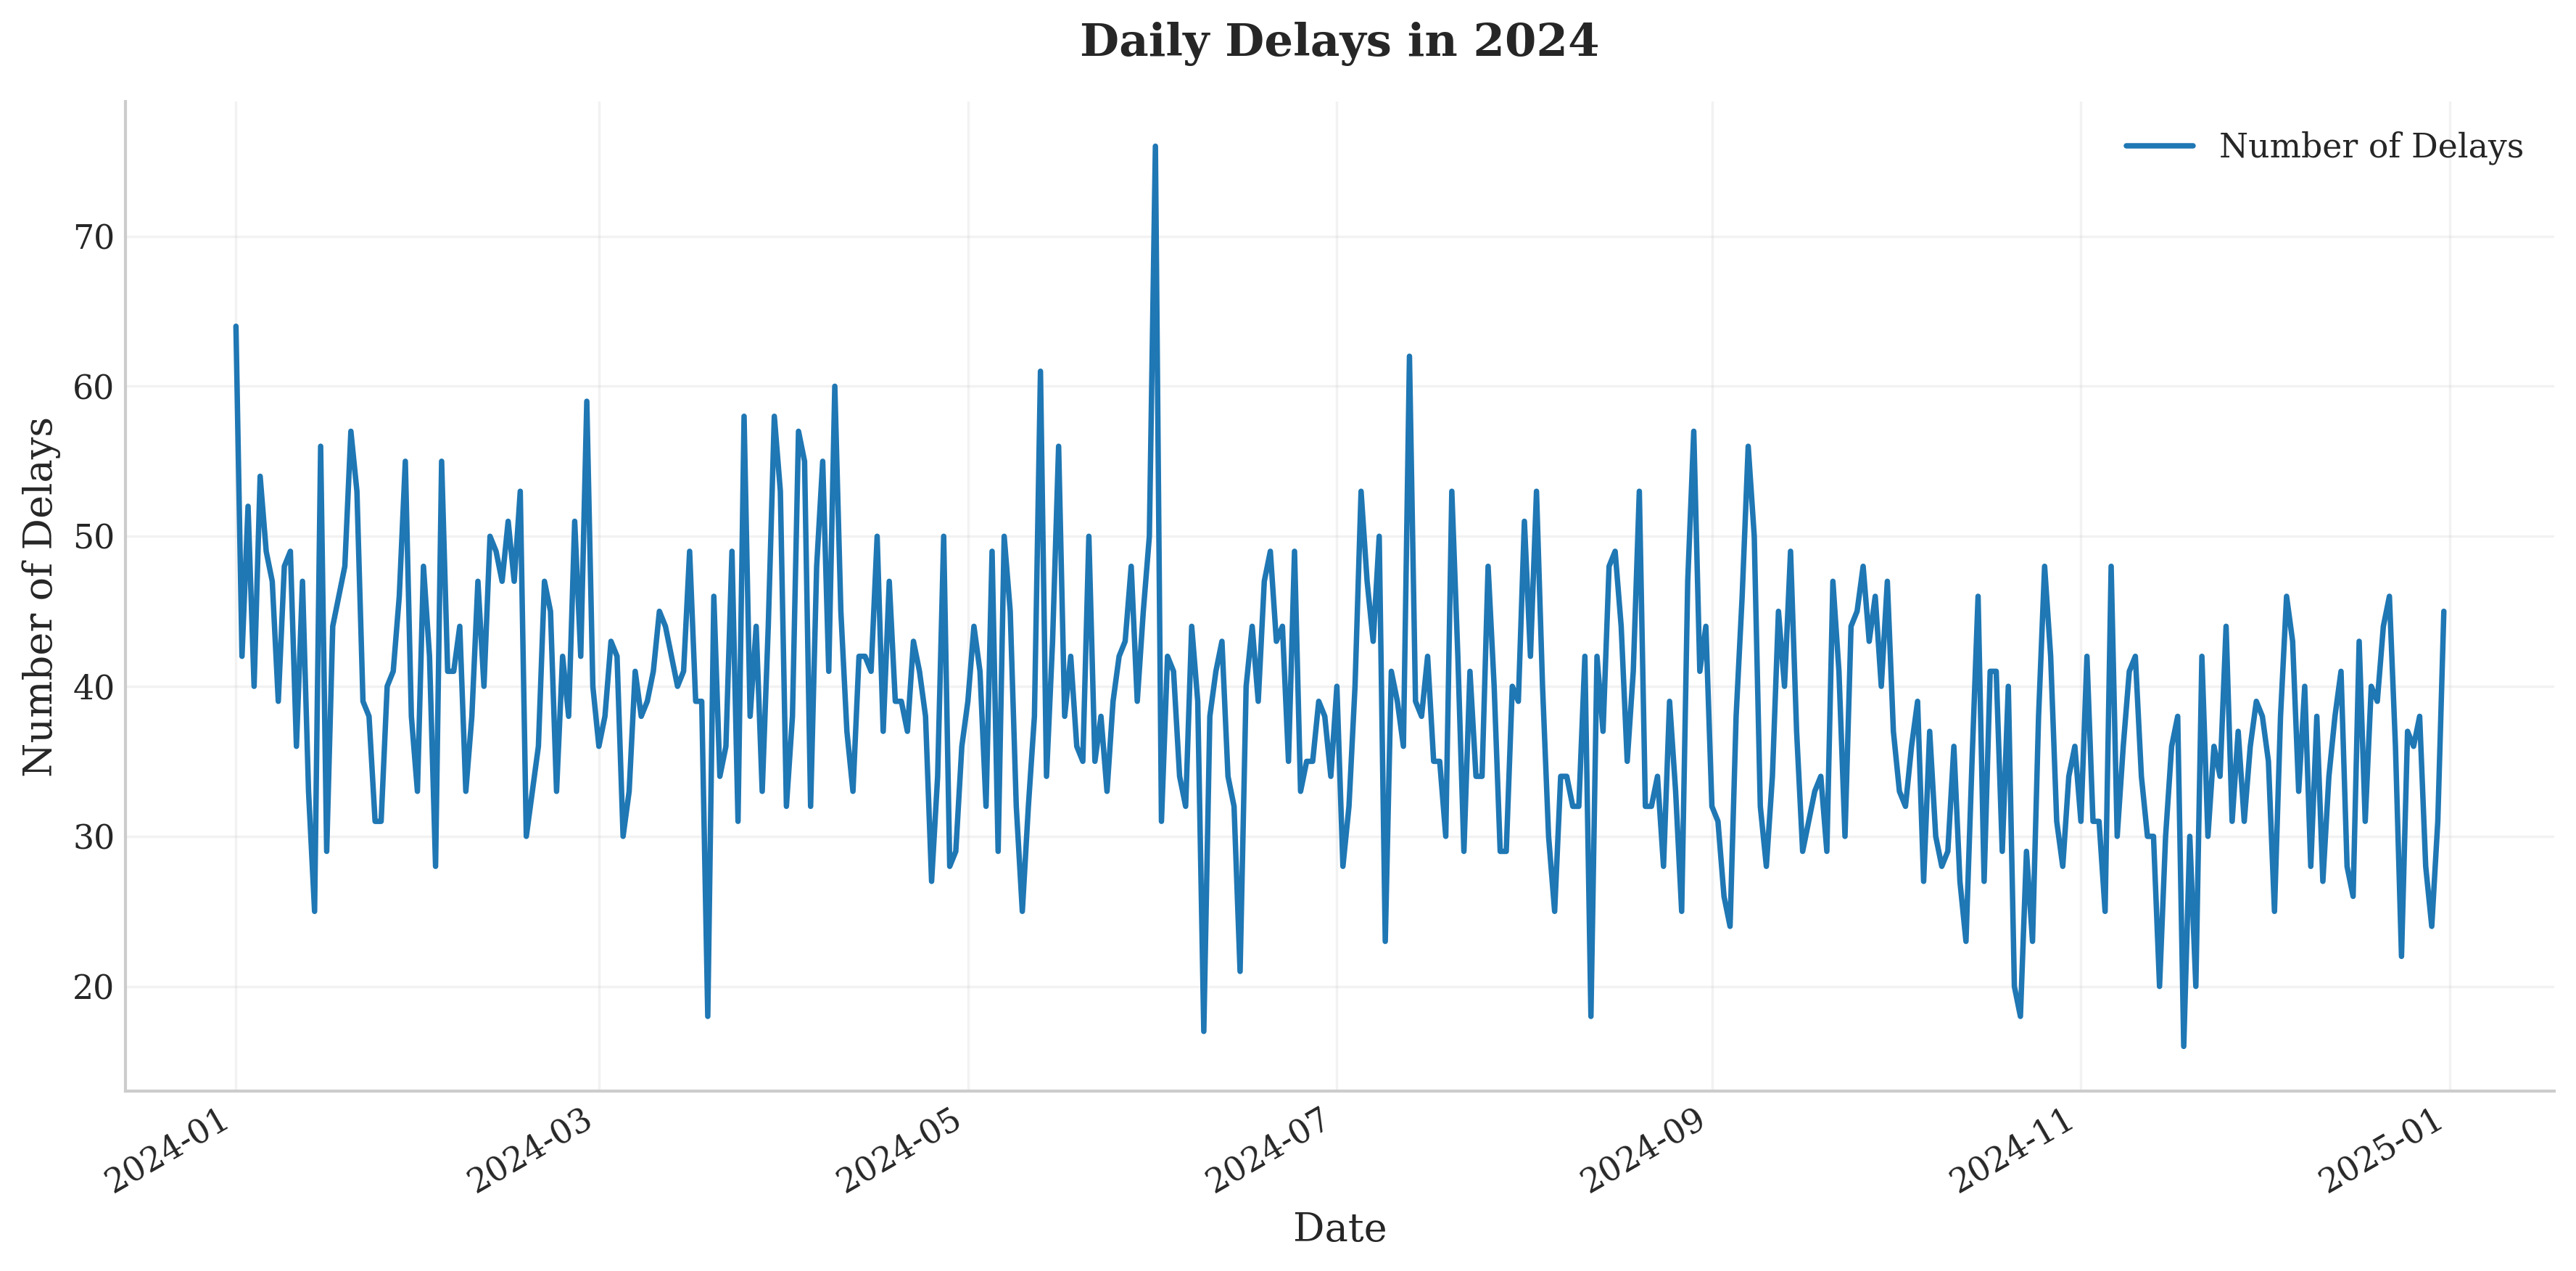

In [5]:
# Publication grade image settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 300,
    "savefig.dpi": 300
})

# Create the figure
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    daily_counts['Date'], 
    daily_counts['number_delay'], 
    color="#1f77b4", 
    linewidth=1.8,
    label="Number of Delays"
)

# Beautify the plot
ax.set_title("Daily Delays in 2024", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Number of Delays")

# Optional: format x-axis ticks for dates
fig.autofmt_xdate()

ax.grid(alpha=0.25)
ax.legend(frameon=False)

# Remove top/right spines for cleaner look
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# Save as high quality image PNG
plt.savefig("daily_delays_2024.png", bbox_inches="tight")

plt.show()

## Plot the histogram of the Incident

In [6]:
delays_2024.Incident.value_counts()

Incident
Operations                  2281
Security                    1881
General Delay               1762
Diversion                   1712
Mechanical                  1683
Cleaning - Unsanitary       1360
Emergency Services          1350
Held By                      740
Collision - TTC Involved     679
Utilized Off Route           331
Investigation                218
Rail/Switches                148
Overhead                      61
Name: count, dtype: int64

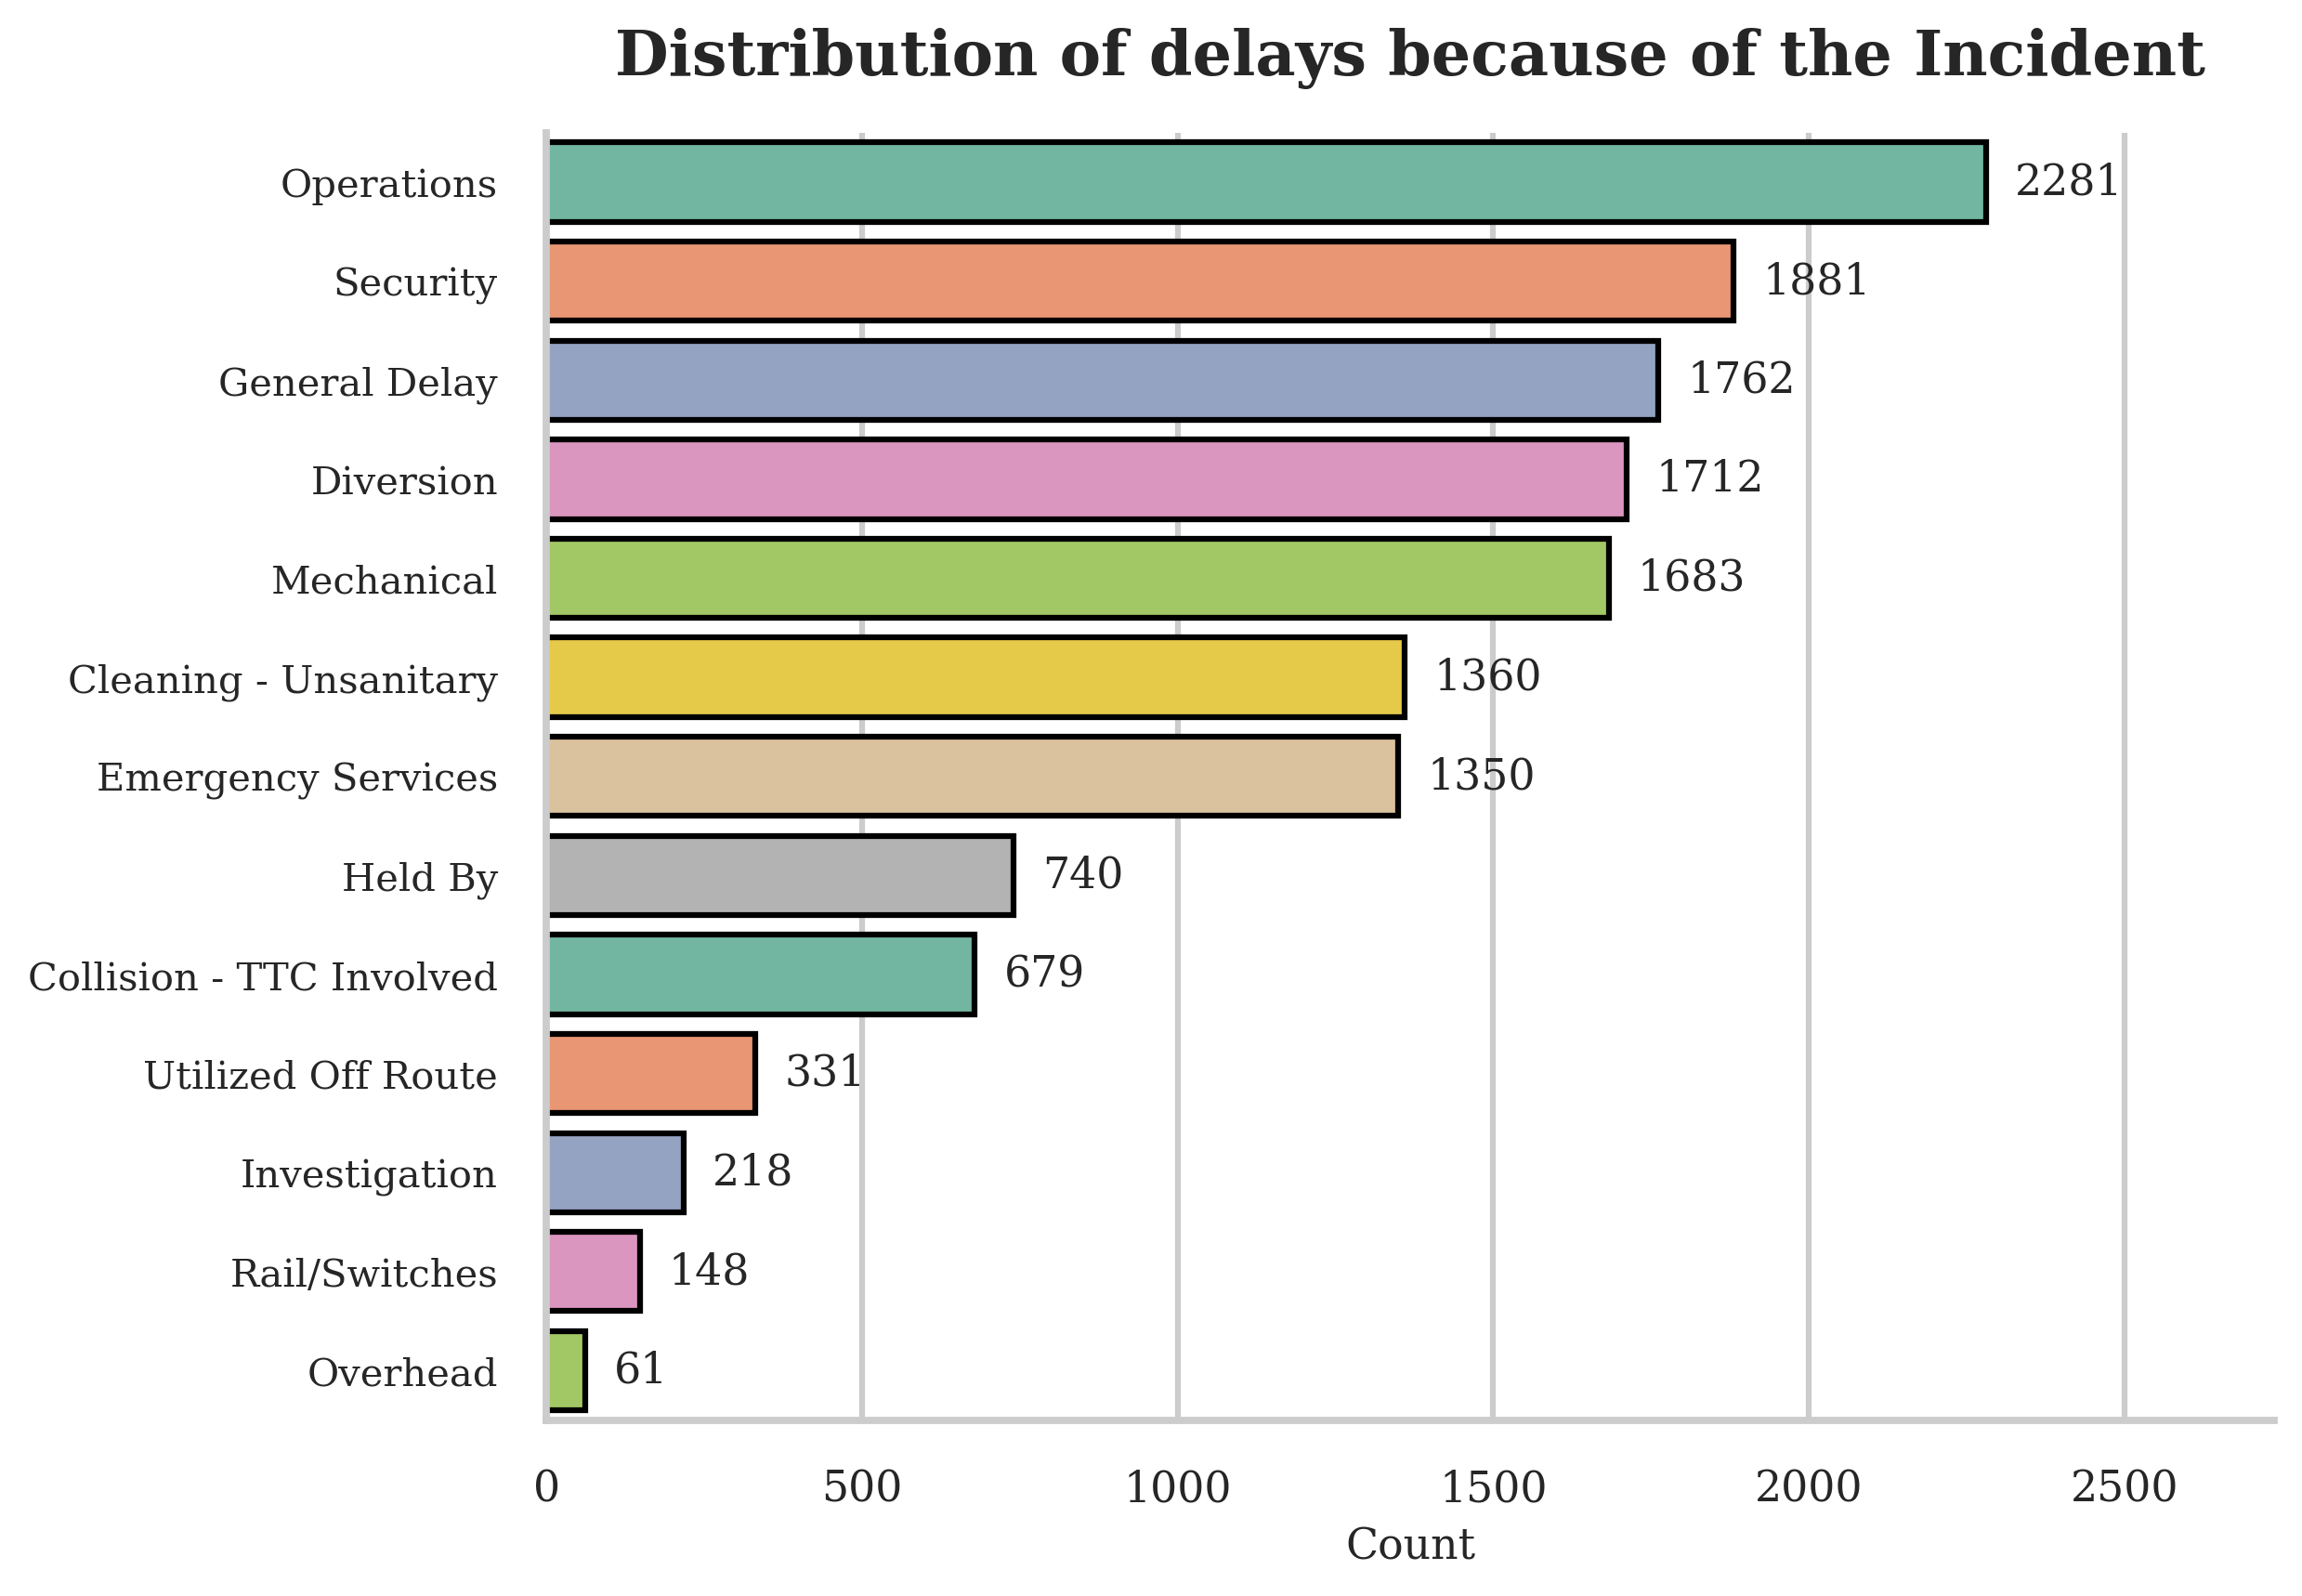

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Count occurrences and build DataFrame
feature = "Incident"
counts = delays_2024[feature].value_counts().reset_index()
counts.columns = [feature, "Count"]

# Custom order (make sure it matches the categories)
custom_order = [
    "Operations", "Security", "General Delay", "Diversion",
    "Mechanical", "Cleaning - Unsanitary", "Emergency Services",
    "Held By", "Collision - TTC Involved", "Utilized Off Route",
    "Investigation", "Rail/Switches", "Overhead"
]

# Seaborn style settings
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "font.family": "serif",
    "savefig.bbox": "tight"
})

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ordered horizontal bar chart
sns.barplot(
    data=counts,
    y=feature,
    x="Count",
    hue=counts.index,
    order=custom_order,   # applies to the y-axis
    palette="Set2",
    edgecolor="black",
    legend=False,
    ax=ax
)

# Add value labels
for i, row in counts.iterrows():
    if row[feature] in custom_order:
        y_pos = custom_order.index(row[feature])
        ax.text(row["Count"] + counts["Count"].max() * 0.02, y_pos, 
                f"{int(row['Count'])}", va="center", fontsize=11)

# Titles and labels
ax.set_title(f"Distribution of delays because of the {feature}", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Count", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, counts["Count"].max() * 1.2)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
sns.despine()

# Save high resolution image
plt.savefig(f"{feature}_distribution_horizontal_bar.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot the number of delays on day of the week 

In [8]:
delays_2024.Day.value_counts()

Day
Saturday     2209
Thursday     2024
Friday       2022
Monday       2020
Wednesday    1994
Sunday       1987
Tuesday      1950
Name: count, dtype: int64

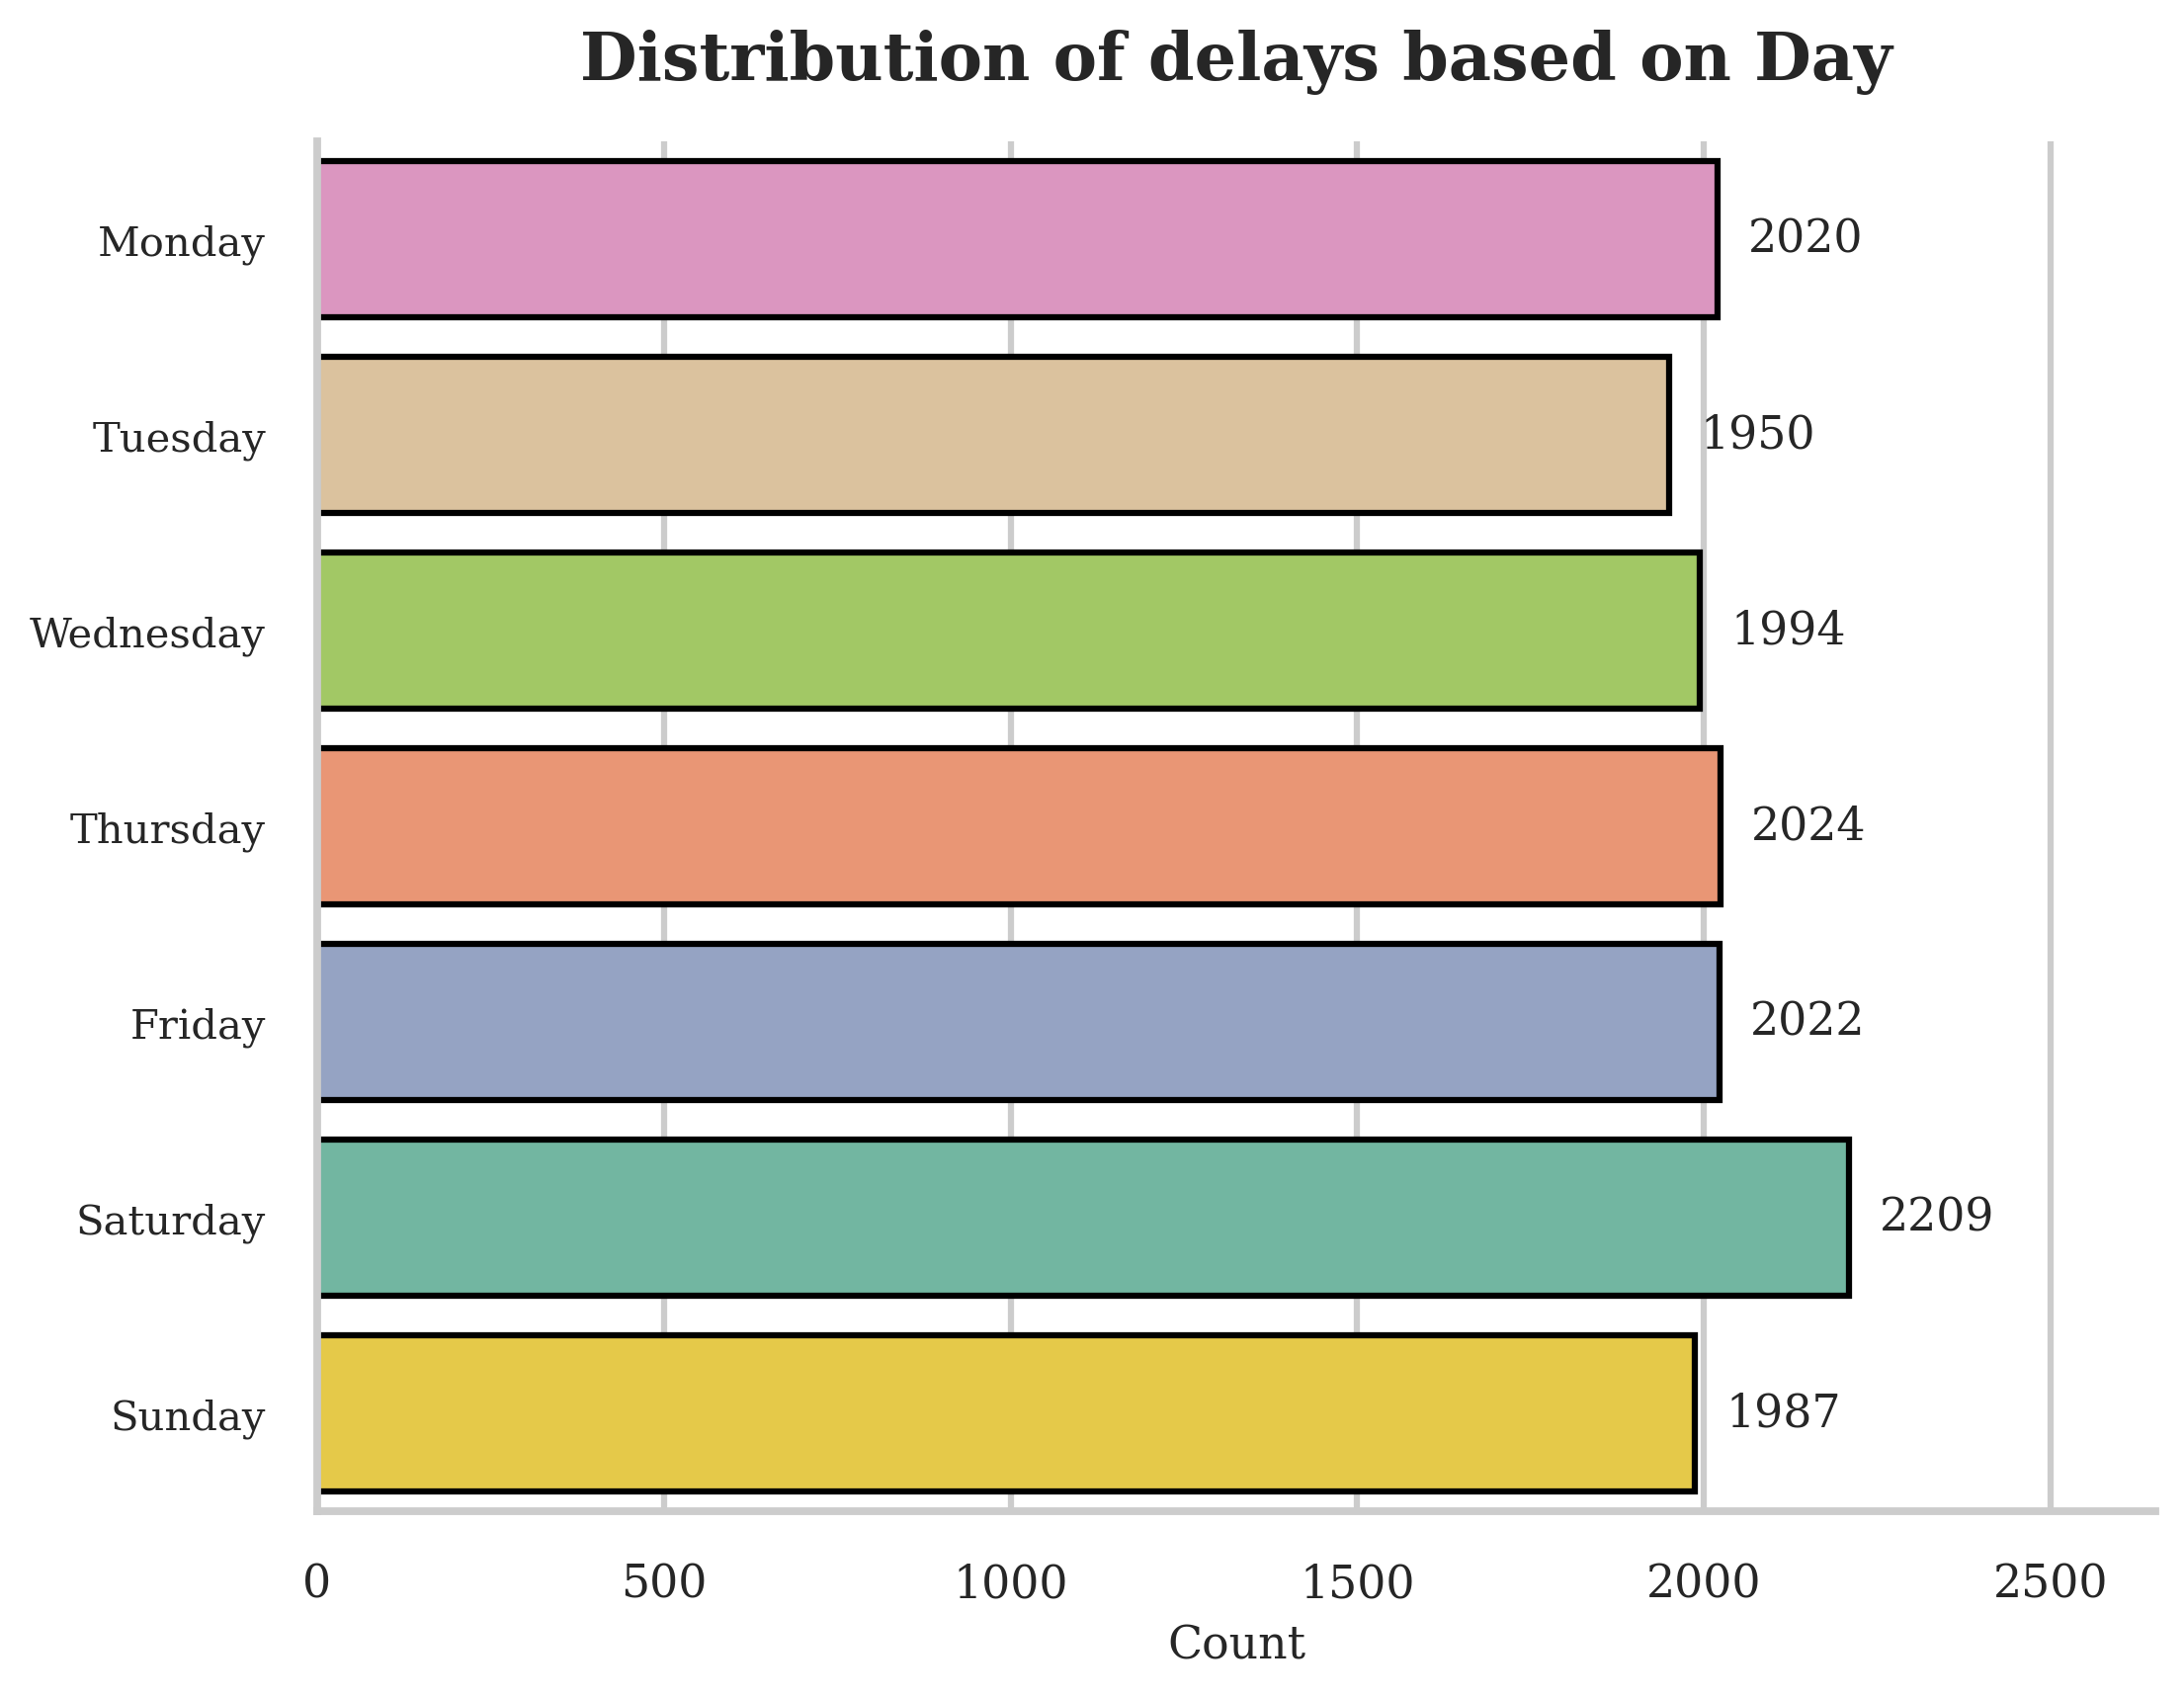

In [9]:
# Count occurrences and build DataFrame
feature = "Day"
counts = delays_2024[feature].value_counts().reset_index()
counts.columns = [feature, "Count"]

# Custom order (make sure it matches the categories)
custom_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]

# Seaborn style settings
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "font.family": "serif",
    "savefig.bbox": "tight"
})

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot ordered horizontal bar chart
sns.barplot(
    data=counts,
    y=feature,
    x="Count",
    hue=counts.index,
    order=custom_order,   # applies to the y-axis
    palette="Set2",
    edgecolor="black",
    legend=False,
    ax=ax
)

# Add value labels
for i, row in counts.iterrows():
    if row[feature] in custom_order:
        y_pos = custom_order.index(row[feature])
        ax.text(row["Count"] + counts["Count"].max() * 0.02, y_pos, 
                f"{int(row['Count'])}", va="center", fontsize=11)

# Titles and labels
ax.set_title(f"Distribution of delays based on {feature}", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Count", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, counts["Count"].max() * 1.2)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
sns.despine()

# Save high resolution image
plt.savefig(f"{feature}_distribution_horizontal_bar.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot the time span of delays

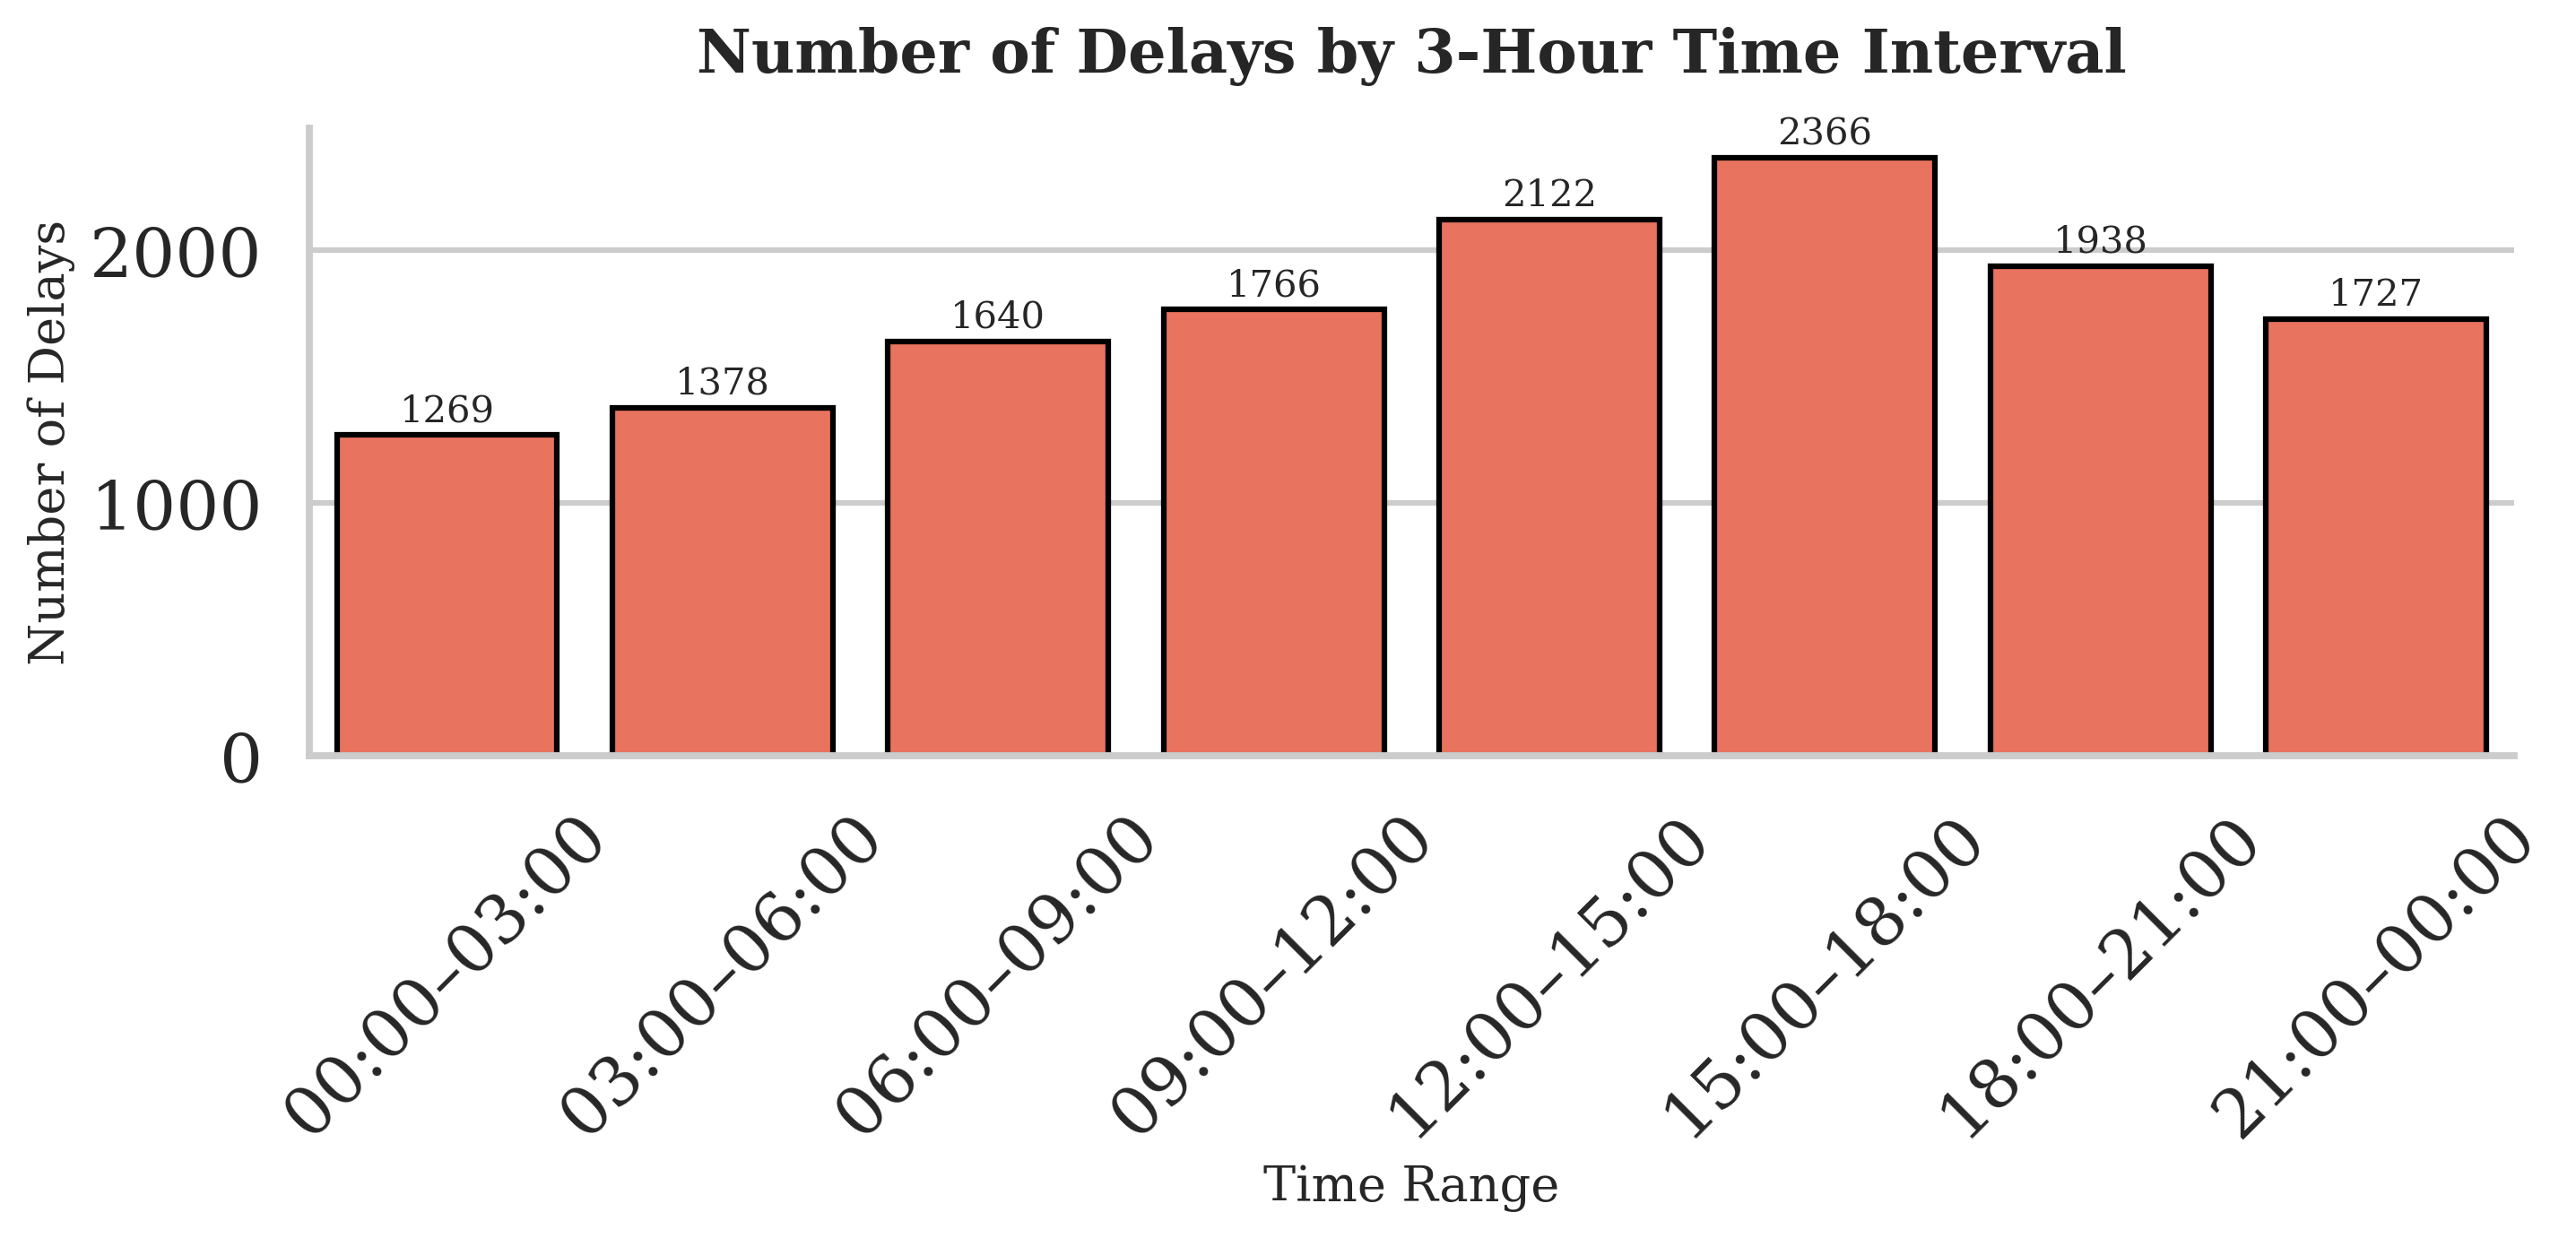

In [10]:
# STEP 1: Parse Time Safely
def parse_time(value):
    if pd.isna(value):
        return np.nan
    for fmt in ("%H:%M:%S", "%H:%M", "%I:%M %p"):  # common time formats
        try:
            return pd.to_datetime(value, format=fmt).time()
        except ValueError:
            continue
    return np.nan

# Apply safe parsing
delays_2024['Time'] = delays_2024['Time'].apply(parse_time)

# STEP 2: Convert to Numeric Hour Value

delays_2024['hour'] = delays_2024['Time'].apply(
    lambda x: x.hour + x.minute/60 if pd.notnull(x) else np.nan
)

# STEP 3: Categorize into 3-Hour Intervals
bins = [0, 3, 6, 9, 12, 15, 18, 21, 24]
labels = [
    "00:00–03:00", "03:00–06:00", "06:00–09:00", "09:00–12:00",
    "12:00–15:00", "15:00–18:00", "18:00–21:00", "21:00–00:00"
]

delays_2024['time_range'] = pd.cut(
    delays_2024['hour'], bins=bins, labels=labels,
    right=False, include_lowest=True
)

# STEP 4: Count and Sort
time_counts = (
    delays_2024['time_range']
    .value_counts()
    .reindex(labels)  # ensure chronological order
    .reset_index()
)
time_counts.columns = ['Time Range', 'Number of Delays']

# STEP 5: Publication-Grade Plot
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x="Time Range", y="Number of Delays", data=time_counts,
    color="tomato", edgecolor="black", ax=ax, legend=False
)

# Annotate values
for i, val in enumerate(time_counts["Number of Delays"]):
    ax.text(i, val + max(time_counts["Number of Delays"]) * 0.01,
            f"{val}", ha="center", va="bottom", fontsize=10)

# Labels and title
ax.set_title("Number of Delays by 3-Hour Time Interval", pad=15)
ax.set_xlabel("Time Range")
ax.set_ylabel("Number of Delays")

plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()

# STEP 6: Save & Show
plt.savefig("delays_by_time_interval.png", dpi=300, bbox_inches="tight")
plt.show()